Downloading modules and data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import gspread

gc = gspread.service_account(filename=r'C:\Users\aser\OneDrive\Документы\Python\Python_practice\Work space\portfolio\first-scarab-391311-91c10fb2730e.json')

tcsg_financial_statements = gc.open('TCSG - отчетность')
tcsg_operating_results = gc.open('TCSG - показатели деятельности')
tcsg_financial_ratios = gc.open('TCSG - финансовые коэффициенты')

tcsg_balanceq = tcsg_financial_statements.get_worksheet(1) 
tcsg_plq = tcsg_financial_statements.get_worksheet(3)
tcsg_orq = tcsg_operating_results.get_worksheet(0)
tcsg_orq2 = tcsg_operating_results.get_worksheet(1)
tcsg_fr = tcsg_financial_ratios.get_worksheet(1)

val_blq = pd.DataFrame(tcsg_balanceq.get('B3:ZZ43'))
val_plq = pd.DataFrame(tcsg_plq.get('B3:ZZ23'))
capital_ratios = pd.DataFrame(tcsg_orq.get('B54:ZZ59')) 
portfolio_structure = pd.DataFrame(tcsg_orq2.get('B14:ZZ20')) 
clients = pd.DataFrame(tcsg_orq2.get('B45:ZZ47')) 
active_clients = pd.DataFrame(tcsg_orq2.get('B52:ZZ53'))
val_fr = pd.DataFrame(tcsg_fr.get('B3:ZZ50'))

pd.set_option('display.float_format', lambda x: '%.2f' % x)

Data Cleaning & Transforming  

In [2]:

val_blq.dropna(axis=0, inplace=True)
val_blq.fillna(0, inplace=True)
val_blq.reset_index(drop=True, inplace=True)
val_blq.iloc[0,1:] = pd.to_datetime(val_blq.iloc[0,1:], format='%d.%m.%Y').dt.date
val_blq.iloc[0,1:] = val_blq.iloc[0,1:].astype('datetime64[ns]').dt.strftime('%d-%m-%Y')
val_blq.iloc[1:,1:] = val_blq.iloc[1:,1:].apply(pd.to_numeric) / 1000000

val_plq.iloc[0,1:] = val_plq.iloc[0,1:].str.slice_replace(1,5,'q')
val_plq.iloc[0,1:] = val_plq.iloc[0,1:].str.slice_replace(7,10,'')
val_plq.iloc[1:,1:] = val_plq.iloc[1:,1:].apply(pd.to_numeric) / 1000000
val_plq.fillna(0, inplace=True)

capital_ratios.iloc[0,0] = 'Company name'
capital_ratios.iloc[1:,1:].replace(',','.', inplace=True, regex=True)
capital_ratios.iloc[1:,1:] = capital_ratios.iloc[1:,1:].apply(pd.to_numeric)

portfolio_structure.iloc[1:,0] = portfolio_structure.iloc[1:,0] + " " + portfolio_structure.iloc[1:,1] 
portfolio_structure.drop(1, axis=1, inplace=True)
portfolio_structure.iloc[1:,1:] = portfolio_structure.iloc[1:,1:].apply(pd.to_numeric)
portfolio_structure.dropna(axis=1, how='any', inplace=True)
portfolio_structure.columns = range(portfolio_structure.shape[1])
portfolio_structure.iloc[0,0] = 'Segment'
portfolio_structure.iloc[0,1:] =  pd.to_datetime(portfolio_structure.iloc[0,1:], format = '%d.%m.%Y').dt.date
portfolio_structure.iloc[0,1:] = portfolio_structure.iloc[0,1:].astype('datetime64[ns]').dt.strftime('%d-%m-%Y')

clients.iloc[1:,0] = clients.iloc[1:,0] + " " + clients.iloc[1:,1]
clients.drop(1, axis=1, inplace=True)
clients.iloc[0,1:] = pd.to_datetime(clients.iloc[0,1:], format = '%d.%m.%Y').dt.date
clients.iloc[0,1:] = clients.iloc[0,1:].astype('datetime64[ns]').dt.strftime('%d-%m-%Y')
clients.iloc[1:,1:] = clients.iloc[1:,1:].apply(pd.to_numeric)

active_clients.iloc[0,1] = 'Percent'
active_clients.drop(0, axis=1, inplace=True)
active_clients.iloc[1,1:] = active_clients.iloc[1,1:].apply(pd.to_numeric)
active_clients.iloc[0,1:] = pd.to_datetime(active_clients.iloc[0,1:], format = '%d.%m.%Y').dt.date
active_clients.iloc[0,1:] = active_clients.iloc[0,1:].astype('datetime64[ns]').dt.strftime('%d-%m-%Y')

val_fr.iloc[1:,1:] = val_fr.iloc[1:,1:].apply(pd.to_numeric)
val_fr.fillna(0, inplace=True)
val_fr.iloc[0,1:] = pd.to_datetime(val_fr.iloc[0,1:], format = '%d.%m.%Y').dt.date
val_fr.iloc[0,1:] = val_fr.iloc[0,1:].astype('datetime64[ns]').dt.strftime('%d-%m-%Y')

Setting colors that will be used later and getting different date formats for visualization.

In [3]:
colors = ['#AFD5C1', '#E68688', '#F1D078', '#8FCCEC', '#EEAF9D', '#C4B2D6', '#A0A0A0']
tcsg_colors = ['#FFE699','#9DC3E6', '#F4B183', '#A9D18E', '#D9D9D9','#C4B2D6', '#7A7A7A']
capr_colors = ['#A9D18E','#FFE699','#B4C7E7','#F4B183','#C00000']
font = {'fontname':'Impact'}
f_colors=['#404040','#BFBFBF', '#D9D9D9']

#Getting dates for the last 20 quarters in diffrent formats. We will need it for futher visualisation 
quarters_analysed = 16

dates_q = val_plq.iloc[0,-quarters_analysed:]
dates_num = val_blq.iloc[0,-quarters_analysed:]
dates_line = np.arange(quarters_analysed)

Here, I've spent a lot of time visualizing different metrics of the company, so when the data is updated, I can press one button to get a full analysis of the last 16 quarters. See the graphs below the code. 

Client base and credit portfolio

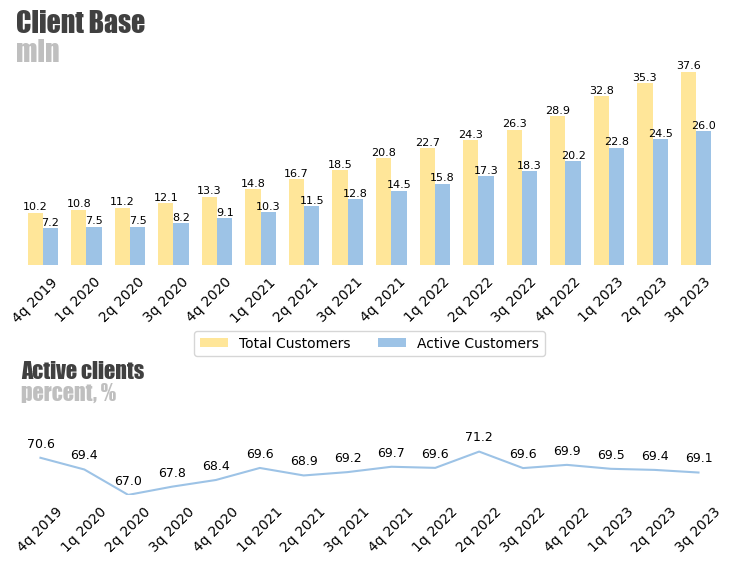

In [4]:
active_clients = clients.iloc[-1,-quarters_analysed:] / clients.iloc[-2,-quarters_analysed:]*100
labels_cl = ['Total Customers','Active Customers']
width_cl = 0.35


clientbase, (clb, acp) = plt.subplots(2,1, figsize=(9,6), height_ratios=(2,1))
for i in range(clients.shape[0]-1):
    clb.bar(dates_line + width_cl * i, clients.iloc[i+1, -quarters_analysed:], label=labels_cl[i], width=width_cl, color=tcsg_colors[i])
clb.xaxis.set_tick_params(rotation=45, labelsize=10)
clb.yaxis.set_visible(False)
clb.set_xticks(dates_line, dates_q)
clb.set_ylim(0, max(clients.iloc[1:, -quarters_analysed:].max())*1.2)
clb.text(-0.45, max(clients.iloc[1:, -quarters_analysed:].max())*1.2, 'Client Base', fontsize=20, **font, color=f_colors[0])    
clb.text(-0.45, max(clients.iloc[1:, -quarters_analysed:].max())*1.05, 'mln', fontsize=20, **font, color=f_colors[1])    
clb.xaxis.set_ticks_position('none')
clb.margins(x=0.01)
for key, spine in clb.spines.items():
    spine.set_visible(False)
for i in range(clients.iloc[1:, -quarters_analysed:].shape[0]):
    for j in range(clients.iloc[1:, -quarters_analysed:].shape[1]):
        clb.text(dates_line[j] + width_cl * i, clients.iloc[1+i, -quarters_analysed+j]+0.5, str(clients.iloc[1+i, -quarters_analysed+j]),
                 ha='center', fontsize=8)
clb.legend(loc='lower center', bbox_to_anchor=(0.5, -0.42),ncol=2)
plt.subplots_adjust(hspace=0.65)
acp.plot(dates_q, active_clients, color=tcsg_colors[1])
acp.xaxis.set_tick_params(rotation=45, labelsize=10)
acp.xaxis.set_ticks_position('none')
acp.yaxis.set_visible(False)
acp.margins(x=0.03)
for key, spines in acp.spines.items():
    spines.set_visible(False)
acp.set_ylim(active_clients.min(), active_clients.max()*1.1)
acp.text(-0.45, active_clients.max()*1.1, 'Active clients', fontsize= 16, **font, color=f_colors[0])
acp.text(-0.45, active_clients.max()*1.07, 'percent, %', fontsize= 16, **font, color=f_colors[1])
for i in range(active_clients.shape[0]):
    acp.text(dates_q.iloc[i], active_clients.iloc[i]+1, str(round(active_clients.iloc[i],1)),
              ha='center', fontsize=9)


Credit portfolio

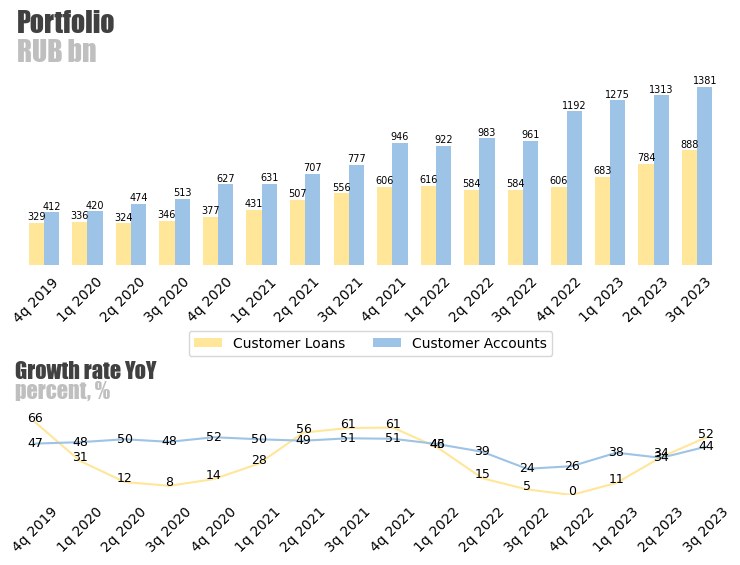

In [5]:
portfolio_volume = val_blq.iloc[[4,19], -quarters_analysed:]
port_growth = val_blq.iloc[[4,19], -quarters_analysed-4:].pct_change(periods=4, axis=1).drop(columns=val_blq.iloc[[4,19], -quarters_analysed-4:].columns[0:4]) * 100
port_labels =['Customer Loans', 'Customer Accounts']
width_port = 0.35


credit_port_graph, (crp, crpg) = plt.subplots(2,1, figsize=(9,6), height_ratios=(2,1))
for i in range(portfolio_volume.shape[0]):
    crp.bar(dates_line + width_port * i , portfolio_volume.iloc[i,:], width = width_port, 
            color=tcsg_colors[i], label=port_labels[i])
for i in range(portfolio_volume.shape[0]):
    for j in range(portfolio_volume.shape[1]):
        crp.text(dates_line[j] + width_port * i, portfolio_volume.iloc[i,j]+20, str(round(portfolio_volume.iloc[i,j])),
                 ha='center', fontsize=7)
crp.set_xticks(dates_line, dates_q)    
crp.xaxis.set_tick_params(rotation=45, labelsize=10)
crp.yaxis.set_visible(False)
crp.set_ylim(0, max(portfolio_volume.max())*1.3)
crp.text(-0.45, max(portfolio_volume.max())*1.3, 'Portfolio', fontsize=20, **font, color=f_colors[0])    
crp.text(-0.45, max(portfolio_volume.max())*1.14, 'RUB bn', fontsize=20, **font, color=f_colors[1])    
crp.xaxis.set_ticks_position('none')
crp.margins(x=0.01)
for key, spine in crp.spines.items():
    spine.set_visible(False)
crp.legend(loc='lower center', bbox_to_anchor=(0.5, -0.42), ncol=2)
plt.subplots_adjust(hspace=0.65)
for i in range(port_growth.shape[0]):
    crpg.plot(dates_q, port_growth.iloc[i], color=tcsg_colors[i])
crpg.xaxis.set_tick_params(rotation=45, labelsize=10)
crpg.xaxis.set_ticks_position('none')
crpg.yaxis.set_visible(False)
crpg.margins(x=0.02)
for key, spines in crpg.spines.items():
    spines.set_visible(False)
crpg.set_ylim(min(port_growth.min()), max(port_growth.max())*1.6)
crpg.text(-0.45, max(port_growth.max())*1.6, 'Growth rate YoY', fontsize= 16, **font, color=f_colors[0])
crpg.text(-0.45, max(port_growth.max())*1.33, 'percent, %', fontsize= 16, **font, color=f_colors[1])
for i in range(port_growth.shape[0]):
    for j in range(port_growth.shape[1]):
        crpg.text(dates_q.iloc[j], port_growth.iloc[i,j]-3*i, str(round(port_growth.iloc[i,j])),
              ha='center', fontsize=9)

Credit Portfolio Structure

Text(-0.45, 1153.6000000000001, 'RUB bn')

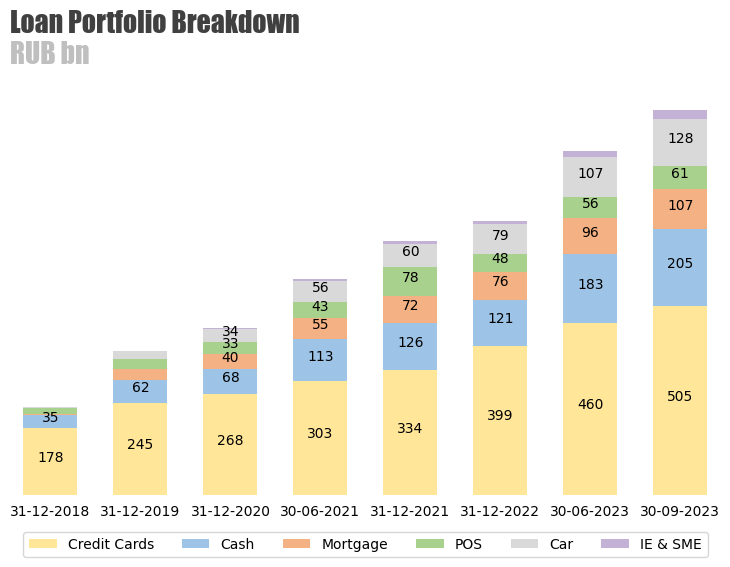

In [6]:
labels_portfolio = ['Credit Cards', 'Cash', 'Mortgage', 'POS', 'Car', 'IE & SME']


credit_port_graph, cred = plt.subplots(figsize=(9,6))
for i in range(portfolio_structure.iloc[1:,1:].shape[0]):
    cred.bar(portfolio_structure.iloc[0,1:], portfolio_structure.iloc[1+i,1:], bottom=np.sum(portfolio_structure.iloc[1:1+i,1:], axis=0),
             color=tcsg_colors[i], label=labels_portfolio[i], width=0.6) 
for i in range(portfolio_structure.iloc[1:,1:].shape[0]):
    for j in range(portfolio_structure.iloc[1:,1:].shape[1]):
        if portfolio_structure.iloc[1+i,1+j] > 30:
            cred.text(portfolio_structure.iloc[0,1+j], np.sum(portfolio_structure.iloc[1:2+i,1+j], axis=0) - portfolio_structure.iloc[1+i,1+j]*0.5, str(round(portfolio_structure.iloc[1+i,1+j])),
                    ha = 'center', fontsize=10)
cred.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=6)
cred.xaxis.set_ticks_position('none')
cred.yaxis.set_visible(False)
cred.margins(x=0.01)
for key, spines in cred.spines.items():
    spines.set_visible(False)
cred.set_ylim(0, np.sum(portfolio_structure.iloc[1:,1:], axis=0).max()*1.2)
cred.text(-0.45, np.sum(portfolio_structure.iloc[1:,1:], axis=0).max()*1.2, 'Loan Portfolio Breakdown', fontsize= 20, **font, color=f_colors[0])
cred.text(-0.45, np.sum(portfolio_structure.iloc[1:,1:], axis=0).max()*1.12, 'RUB bn', fontsize= 20, **font, color=f_colors[1])    
    
    

Credit Portfolio Structure in percents

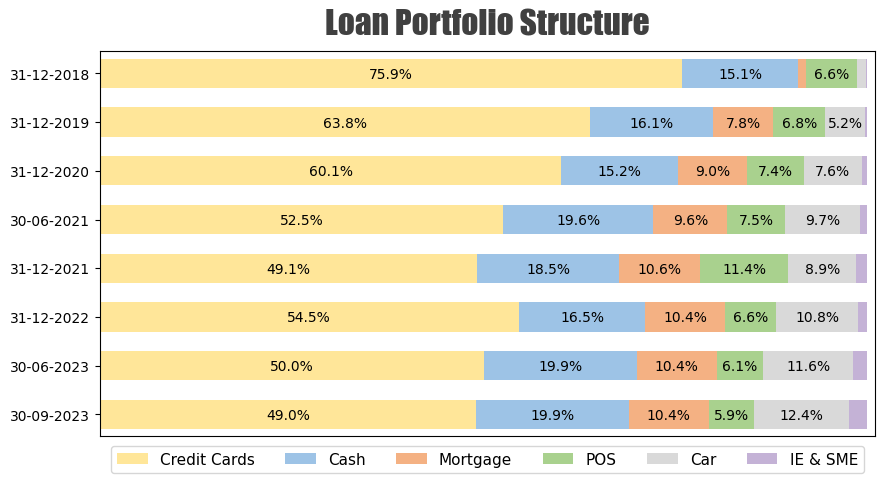

In [7]:
port_structure_perc = portfolio_structure.iloc[1:,1:] / np.sum(portfolio_structure.iloc[1:,1:], axis=0)*100
    
    
port_perc, portp = plt.subplots(figsize=(10,5))
portp.set_title('Loan Portfolio Structure', fontsize=24,y=1.02, **font, color=f_colors[0])
portp.set_yticks(dates_line[:8], portfolio_structure.iloc[0,1:])
portp.invert_yaxis()
portp.xaxis.set_visible(False)
portp.margins(y=0.02, x=0.01)
for i in range(port_structure_perc.shape[0]):
    portp.barh(dates_line[:8], width=port_structure_perc.iloc[i,:], color=tcsg_colors[i], label=labels_portfolio[i],
             left = np.sum(port_structure_perc.iloc[:i,:], axis=0), height=0.6)
portp.legend(loc = 'lower center', ncol=6, bbox_to_anchor=(0.5,-0.115), fontsize=11)
for i in range(port_structure_perc.shape[0]):
    for j in range(port_structure_perc.shape[1]):
        if port_structure_perc.iloc[i,j] >2.8:
            portp.text(np.sum(port_structure_perc.iloc[:i+1,j], axis=0) - port_structure_perc.iloc[i,j]*0.5, dates_line[j]+0.1,
                     str(round(port_structure_perc.iloc[i,j], 1))+"%", ha='center', fontsize=10)


Interest Income

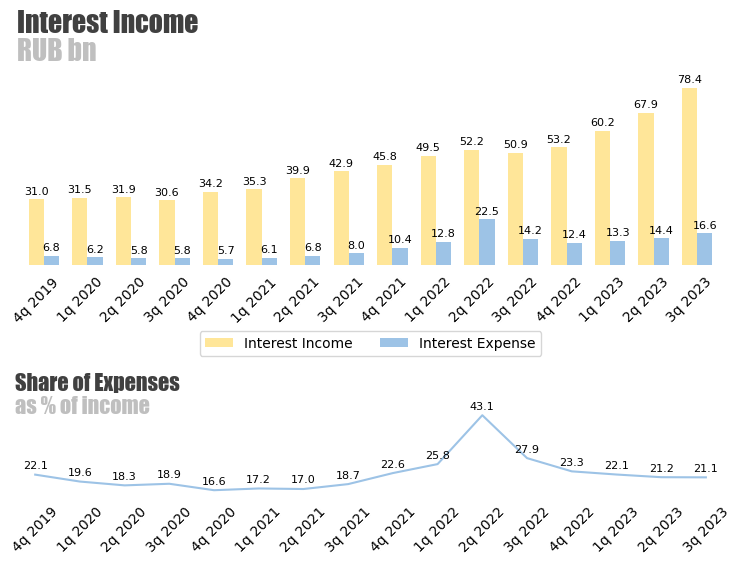

In [8]:

interest_inc = pd.DataFrame([val_plq.iloc[1, -quarters_analysed:], -np.sum(val_plq.iloc[[2,3], -quarters_analysed:], axis=0)], index=['Interest Income', 'Interest Expense'])
intexp_share = np.sum(val_plq.iloc[[2,3], -quarters_analysed:], axis=0) / val_plq.iloc[1, -quarters_analysed:] *-100


interest_graph, (intg, intp) = plt.subplots(2,1,figsize=(9,6), height_ratios=(2,1))
for i in range(interest_inc.shape[0]):
    intg.bar(dates_line + width_port * i , interest_inc.iloc[i,:], width = width_port, 
            color=tcsg_colors[i], label=interest_inc.index[i])
for i in range(portfolio_volume.shape[0]):
    for j in range(interest_inc.shape[1]):
        intg.text(dates_line[j] + width_port * i, interest_inc.iloc[i,j]+2, str(round(interest_inc.iloc[i,j],1)),
                 ha='center', fontsize=8)
intg.set_xticks(dates_line, dates_q)    
intg.xaxis.set_tick_params(rotation=45, labelsize=10)
intg.yaxis.set_visible(False)
intg.set_ylim(min(interest_inc.min())*0.5, max(interest_inc.max())*1.3)
intg.text(-0.45, max(interest_inc.max())*1.3, 'Interest Income', fontsize=20, **font, color=f_colors[0])    
intg.text(-0.45, max(interest_inc.max())*1.15, 'RUB bn', fontsize=20, **font, color=f_colors[1])    
intg.xaxis.set_ticks_position('none')
intg.margins(x=0.01)
for key, spine in intg.spines.items():
    spine.set_visible(False)
intg.legend(loc='lower center', bbox_to_anchor=(0.5, -0.42), ncol=2)
plt.subplots_adjust(hspace=0.65)
intp.plot(dates_q, intexp_share, color=tcsg_colors[1])
intp.xaxis.set_tick_params(rotation=45, labelsize=10)
intp.yaxis.set_visible(False)
intp.set_ylim(intexp_share.min()*0.9, intexp_share.max()*1.3)
intp.text(-0.45, intexp_share.max()*1.2, 'Share of Expenses', fontsize=16, **font, color=f_colors[0])    
intp.text(-0.45, intexp_share.max()*1.01, 'as % of income', fontsize=16, **font, color=f_colors[1])    
intp.xaxis.set_ticks_position('none')
intp.margins(x=0.02)
for key, spine in intp.spines.items():
    spine.set_visible(False)
for i in range(intexp_share.shape[0]):
    intp.text(dates_q.iloc[i], intexp_share.iloc[i]+2, str(round(intexp_share.iloc[i],1)),
                 ha='center', fontsize=8)

Net Interest Income

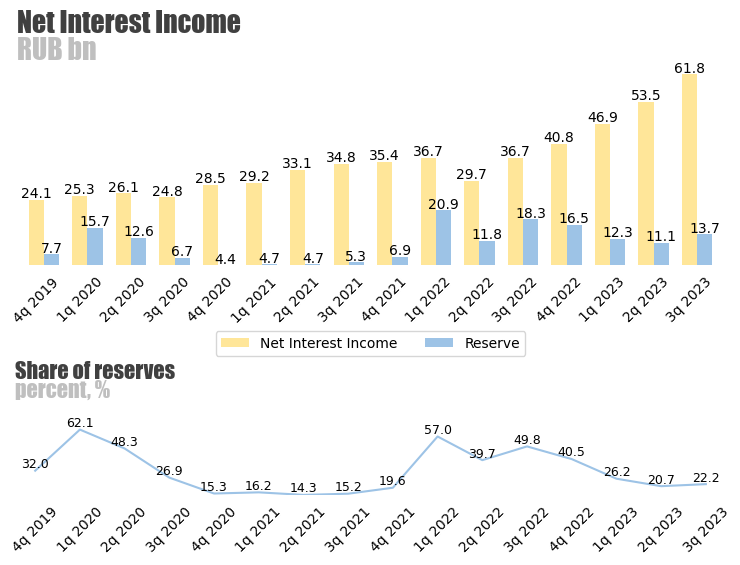

In [9]:

val_nii = pd.DataFrame([val_plq.iloc[4, -quarters_analysed:], -val_plq.iloc[5, -quarters_analysed:]])
labels_nii = ['Net Interest Income', 'Reserve']
reservs_share = -val_plq.iloc[5, -quarters_analysed:] / val_plq.iloc[4, -quarters_analysed:] *100
width_nii = 0.35


nii_graph, (nii, niir) = plt.subplots(2,1 , figsize=(9,6), height_ratios=(2,1))
for i in range(val_nii.shape[0]):
    nii.bar(dates_line + width_nii * i, val_nii.iloc[i], color=tcsg_colors[i], label=labels_nii[i], width=width_nii)
for i in range(val_nii.shape[0]):
    for j in range(val_nii.shape[1]):
        nii.text(dates_line[j] + width_nii * i, val_nii.iloc[i, j]+0.5, str(round(val_nii.iloc[i, j],1)),
                 ha = 'center', fontsize=10)
nii.set_xticks(dates_line, dates_q)
nii.xaxis.set_tick_params(rotation=45, labelsize=10)
nii.xaxis.set_ticks_position('none')
nii.yaxis.set_visible(False)
for key, spines in nii.spines.items():
    spines.set_visible(False)
nii.set_ylim(min(val_nii.iloc[:2].min()), max(val_nii.iloc[:2].max())*1.2)
nii.text(-0.45, max(val_nii.iloc[:2].max())*1.2, 'Net Interest Income', fontsize= 20, **font, color=f_colors[0])
nii.text(-0.45, max(val_nii.iloc[:2].max())*1.07, 'RUB bn', fontsize= 20, **font, color=f_colors[1])
nii.legend(loc='lower center', bbox_to_anchor=(0.5, -0.42), ncol=2)
nii.margins(x=0.01)
plt.subplots_adjust(hspace=0.65)
niir.plot(dates_q, reservs_share, color=tcsg_colors[1])
niir.xaxis.set_tick_params(rotation=45, labelsize=10)
niir.xaxis.set_ticks_position('none')
niir.yaxis.set_visible(False)
niir.margins(x=0.02)
for key, spines in niir.spines.items():
    spines.set_visible(False)
niir.set_ylim(reservs_share.min(), reservs_share.max()*1.6)
niir.text(-0.45, reservs_share.max()*1.6, 'Share of reserves', fontsize= 16, **font, color=f_colors[0])
niir.text(-0.45, reservs_share.max()*1.38, 'percent, %', fontsize= 16, **font, color=f_colors[1])
for i in range(reservs_share.shape[0]):
    niir.text(dates_q.iloc[i], reservs_share.iloc[i]+2, str(round(reservs_share.iloc[i],1)),
              ha='center', fontsize=9)


NII after reserves 

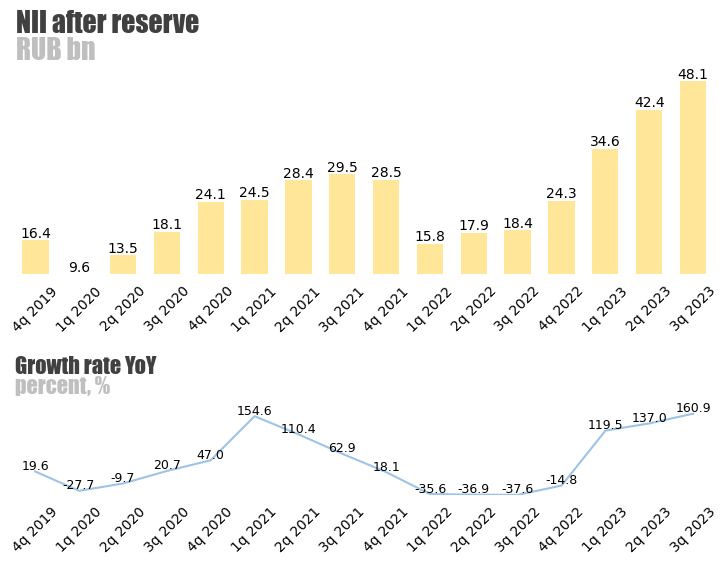

In [10]:

nii_ar = val_plq.iloc[6, -quarters_analysed:]
nii_ar_growth = val_plq.iloc[6, -quarters_analysed-4:].pct_change(periods=4).drop(index=val_plq.iloc[6, -quarters_analysed-4:].index[0:4])*100


nii__ar_graph, (niig, niigp) = plt.subplots(2,1 , figsize=(9,6), height_ratios=(2,1))
niig.bar(dates_q, nii_ar, color=tcsg_colors[0],  width=0.6)
for i in range(nii_ar.shape[0]):
    niig.text(dates_q.iloc[i], nii_ar.iloc[i]+0.5, str(round(nii_ar.iloc[i],1)),
                 ha = 'center', fontsize=10)
niig.xaxis.set_tick_params(rotation=45, labelsize=10)
niig.xaxis.set_ticks_position('none')
niig.yaxis.set_visible(False)
for key, spines in niig.spines.items():
    spines.set_visible(False)
niig.set_ylim(nii_ar.min(), nii_ar.max()*1.2)
niig.text(-0.45, nii_ar.max()*1.2, 'NII after reserve', fontsize= 20, **font, color=f_colors[0])
niig.text(-0.45, nii_ar.max()*1.09, 'RUB bn', fontsize= 20, **font, color=f_colors[1])
niig.margins(x=0.01)
plt.subplots_adjust(hspace=0.55)
niigp.plot(dates_q, nii_ar_growth, color=tcsg_colors[1])
niigp.xaxis.set_tick_params(rotation=45, labelsize=10)
niigp.xaxis.set_ticks_position('none')
niigp.yaxis.set_visible(False)
niigp.margins(x=0.03)
for key, spines in niigp.spines.items():
    spines.set_visible(False)
niigp.set_ylim(nii_ar_growth.min(), nii_ar_growth.max()*1.6)
niigp.text(-0.45, nii_ar_growth.max()*1.6, 'Growth rate YoY', fontsize= 16, **font, color=f_colors[0])
niigp.text(-0.45, nii_ar_growth.max()*1.3, 'percent, %', fontsize= 16, **font, color=f_colors[1])
for i in range(nii_ar_growth.shape[0]):
    niigp.text(dates_q.iloc[i], nii_ar_growth.iloc[i]+4, str(round(nii_ar_growth.iloc[i],1)),
              ha='center', fontsize=9)

Commissions

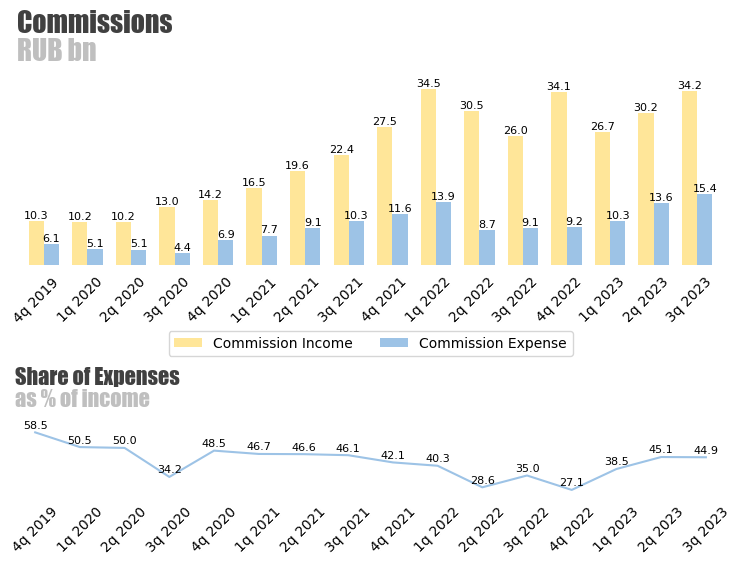

In [11]:
commissions = abs(val_plq.iloc[[7,8], -quarters_analysed:])
labels_com = ['Commission Income', 'Commission Expense']
commissions_perc = val_plq.iloc[8, -quarters_analysed:] / val_plq.iloc[7, -quarters_analysed:] * -100


commission_graph, (cmg, cmp) = plt.subplots(2,1,figsize=(9,6), height_ratios=(2,1))
for i in range(interest_inc.shape[0]):
    cmg.bar(dates_line + width_port * i , commissions.iloc[i], width = width_port, 
            color=tcsg_colors[i], label=labels_com[i])
for i in range(commissions.shape[0]):
    for j in range(commissions.shape[1]):
        cmg.text(dates_line[j] + width_port * i, commissions.iloc[i,j]+0.4, str(round(commissions.iloc[i,j],1)),
                 ha='center', fontsize=8)
cmg.set_xticks(dates_line, dates_q)    
cmg.xaxis.set_tick_params(rotation=45, labelsize=10)
cmg.yaxis.set_visible(False)
cmg.set_ylim(min(commissions.min())*0.5, max(commissions.max())*1.3)
cmg.text(-0.45, max(commissions.max())*1.3, 'Commissions', fontsize=20, **font, color=f_colors[0])    
cmg.text(-0.45, max(commissions.max())*1.15, 'RUB bn', fontsize=20, **font, color=f_colors[1])    
cmg.xaxis.set_ticks_position('none')
cmg.margins(x=0.01)
for key, spine in cmg.spines.items():
    spine.set_visible(False)
cmg.legend(loc='lower center', bbox_to_anchor=(0.5, -0.42), ncol=2)
plt.subplots_adjust(hspace=0.65)
cmp.plot(dates_q, commissions_perc, color=tcsg_colors[1])
cmp.xaxis.set_tick_params(rotation=45, labelsize=10)
cmp.yaxis.set_visible(False)
cmp.set_ylim(commissions_perc.min()*0.9, commissions_perc.max()*1.5)
cmp.text(-0.45, commissions_perc.max()*1.44, 'Share of Expenses', fontsize=16, **font, color=f_colors[0])    
cmp.text(-0.45, commissions_perc.max()*1.24, 'as % of income', fontsize=16, **font, color=f_colors[1])    
cmp.xaxis.set_ticks_position('none')
cmp.margins(x=0.02)
for key, spine in cmp.spines.items():
    spine.set_visible(False)
for i in range(commissions_perc.shape[0]):
    cmp.text(dates_q.iloc[i], commissions_perc.iloc[i]+2, str(round(commissions_perc.iloc[i],1)),
                 ha='center', fontsize=8)

Net Commissions

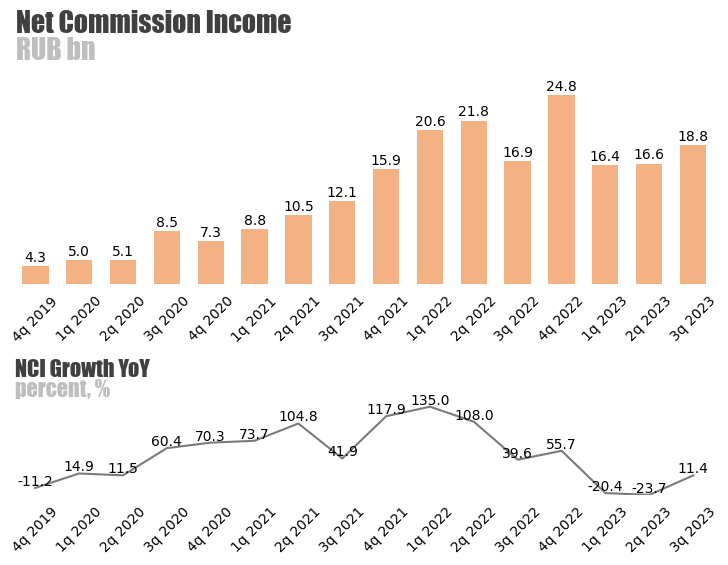

In [12]:

net_commission = val_plq.iloc[7, -quarters_analysed:] + val_plq.iloc[8, -quarters_analysed:]
nci_perc = np.sum(val_plq.iloc[[7,8], -quarters_analysed-4:], axis=0).pct_change(periods=4).drop(index=np.sum(val_plq.iloc[[7,8], -quarters_analysed-4:], axis=0).index[0:4])*100


nci_graph, (nci, ncip) = plt.subplots(2,1,figsize=(9,6), height_ratios=(2,1))
nci.bar(dates_q, net_commission, color=tcsg_colors[2], width=0.6)
for i in range(net_commission.shape[0]):
    nci.text(dates_q.iloc[i], net_commission.iloc[i]+0.5, str(round(net_commission.iloc[i],1)),
            ha='center', fontsize=10)
nci.xaxis.set_tick_params(rotation=45, labelsize=10)
nci.yaxis.set_visible(False)
nci.set_ylim(net_commission.min()*0.5, net_commission.max()*1.3)
nci.text(-0.45, net_commission.max()*1.3, 'Net Commission Income', fontsize=20, **font, color=f_colors[0])    
nci.text(-0.45, net_commission.max()*1.17, 'RUB bn', fontsize=20, **font, color=f_colors[1])    
nci.xaxis.set_ticks_position('none')
nci.margins(x=0.01)
for key, spine in nci.spines.items():
    spine.set_visible(False)
plt.subplots_adjust(hspace=0.45)
ncip.plot(dates_q, nci_perc, color=tcsg_colors[-1])
ncip.xaxis.set_tick_params(rotation=45, labelsize=10)
ncip.yaxis.set_visible(False)
ncip.set_ylim(nci_perc.min(), nci_perc.max()*1.5)
ncip.text(-0.45, nci_perc.max()*1.4, 'NCI Growth YoY', fontsize=16, **font, color=f_colors[0])    
ncip.text(-0.45, nci_perc.max()*1.14, 'percent, %', fontsize=16, **font, color=f_colors[1])    
ncip.xaxis.set_ticks_position('none')
ncip.margins(x=0.03)
for key, spine in ncip.spines.items():
    spine.set_visible(False)
for i in range(nci_perc.shape[0]):
    ncip.text(dates_q.iloc[i], nci_perc.iloc[i]+4, str(round(nci_perc.iloc[i],1)),
                 ha='center', fontsize=10)

Insurance Business

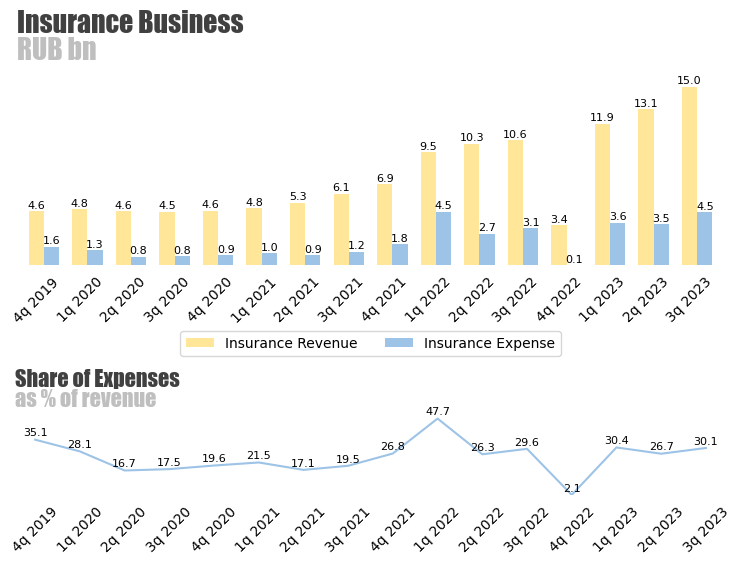

In [13]:
insurance_rev = abs(val_plq.iloc[[14,15], -quarters_analysed:])
labels_ins = ['Insurance Revenue', 'Insurance Expense']
insurance_perc = val_plq.iloc[15, -quarters_analysed:] / val_plq.iloc[14, -quarters_analysed:] * -100


insurance_graph, (insg, insp) = plt.subplots(2,1,figsize=(9,6), height_ratios=(2,1))
for i in range(insurance_rev.shape[0]):
    insg.bar(dates_line + width_port * i , insurance_rev.iloc[i], width = width_port, 
            color=tcsg_colors[i], label=labels_ins[i])
for i in range(insurance_rev.shape[0]):
    for j in range(insurance_rev.shape[1]):
        insg.text(dates_line[j] + width_port * i, insurance_rev.iloc[i,j]+0.2, str(round(insurance_rev.iloc[i,j],1)),
                 ha='center', fontsize=8)
insg.set_xticks(dates_line, dates_q)    
insg.xaxis.set_tick_params(rotation=45, labelsize=10)
insg.yaxis.set_visible(False)
insg.set_ylim(min(insurance_rev.min())*0.5, max(insurance_rev.max())*1.3)
insg.text(-0.45, max(insurance_rev.max())*1.3, 'Insurance Business', fontsize=20, **font, color=f_colors[0])    
insg.text(-0.45, max(insurance_rev.max())*1.15, 'RUB bn', fontsize=20, **font, color=f_colors[1])    
insg.xaxis.set_ticks_position('none')
insg.margins(x=0.01)
for key, spine in insg.spines.items():
    spine.set_visible(False)
insg.legend(loc='lower center', bbox_to_anchor=(0.5, -0.42), ncol=2)
plt.subplots_adjust(hspace=0.65)
insp.plot(dates_q, insurance_perc, color=tcsg_colors[1])
insp.xaxis.set_tick_params(rotation=45, labelsize=10)
insp.yaxis.set_visible(False)
insp.set_ylim(insurance_perc.min(), insurance_perc.max()*1.5)
insp.text(-0.45, insurance_perc.max()*1.4, 'Share of Expenses', fontsize=16, **font, color=f_colors[0])    
insp.text(-0.45, insurance_perc.max()*1.15, 'as % of revenue', fontsize=16, **font, color=f_colors[1])    
insp.xaxis.set_ticks_position('none')
insp.margins(x=0.02)
for key, spine in insp.spines.items():
    spine.set_visible(False)
for i in range(insurance_perc.shape[0]):
    insp.text(dates_q.iloc[i], insurance_perc.iloc[i]+2, str(round(insurance_perc.iloc[i],1)),
                 ha='center', fontsize=8)


Insurance Business Net Income

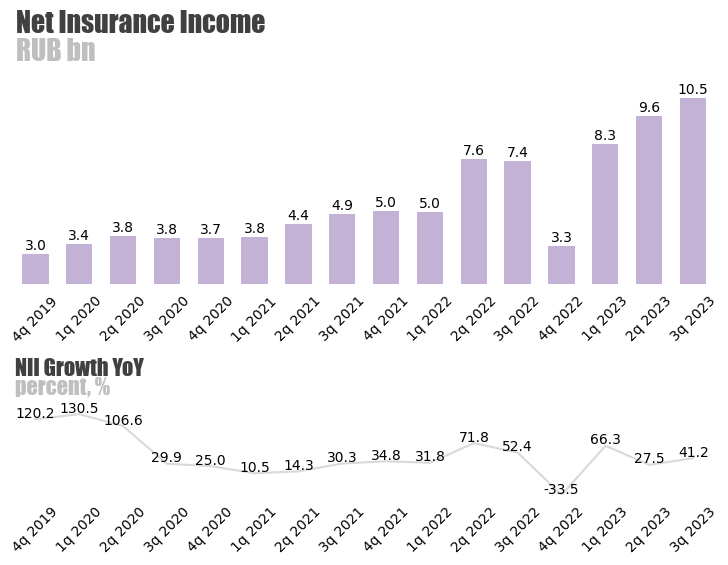

In [14]:
insurance_net = np.sum(val_plq.iloc[[14,15], -quarters_analysed:], axis = 0)
insurance_growth = np.sum(val_plq.iloc[[14,15], -quarters_analysed-4:], axis = 0).pct_change(periods=4).drop(index=np.sum(val_plq.iloc[[14,15], -quarters_analysed-4:], axis=0).index[0:4])*100


insurance_graph, (inn, inng) = plt.subplots(2,1,figsize=(9,6), height_ratios=(2,1))
inn.bar(dates_q, insurance_net, color=tcsg_colors[5], width=0.6)
for i in range(insurance_net.shape[0]):
    inn.text(dates_q.iloc[i], insurance_net.iloc[i]+0.2, str(round(insurance_net.iloc[i],1)),
            ha='center', fontsize=10)
inn.xaxis.set_tick_params(rotation=45, labelsize=10)
inn.yaxis.set_visible(False)
inn.set_ylim(insurance_net.min()*0.5, insurance_net.max()*1.3)
inn.text(-0.45, insurance_net.max()*1.3, 'Net Insurance Income', fontsize=20, **font, color=f_colors[0])    
inn.text(-0.45, insurance_net.max()*1.17, 'RUB bn', fontsize=20, **font, color=f_colors[1])    
inn.xaxis.set_ticks_position('none')
inn.margins(x=0.01)
for key, spine in inn.spines.items():
    spine.set_visible(False)
plt.subplots_adjust(hspace=0.45)
inng.plot(dates_q, insurance_growth, color=tcsg_colors[4])
inng.xaxis.set_tick_params(rotation=45, labelsize=10)
inng.yaxis.set_visible(False)
inng.set_ylim(insurance_growth.min(), insurance_growth.max()*1.7)
inng.text(-0.45, insurance_growth.max()*1.6, 'NII Growth YoY', fontsize=16, **font, color=f_colors[0])    
inng.text(-0.45, insurance_growth.max()*1.3, 'percent, %', fontsize=16, **font, color=f_colors[1])    
inng.xaxis.set_ticks_position('none')
inng.margins(x=0.03)
for key, spine in inng.spines.items():
    spine.set_visible(False)
for i in range(insurance_growth.shape[0]):
    inng.text(dates_q.iloc[i], insurance_growth.iloc[i]+3, str(round(insurance_growth.iloc[i],1)),
                 ha='center', fontsize=10)


Operating Income

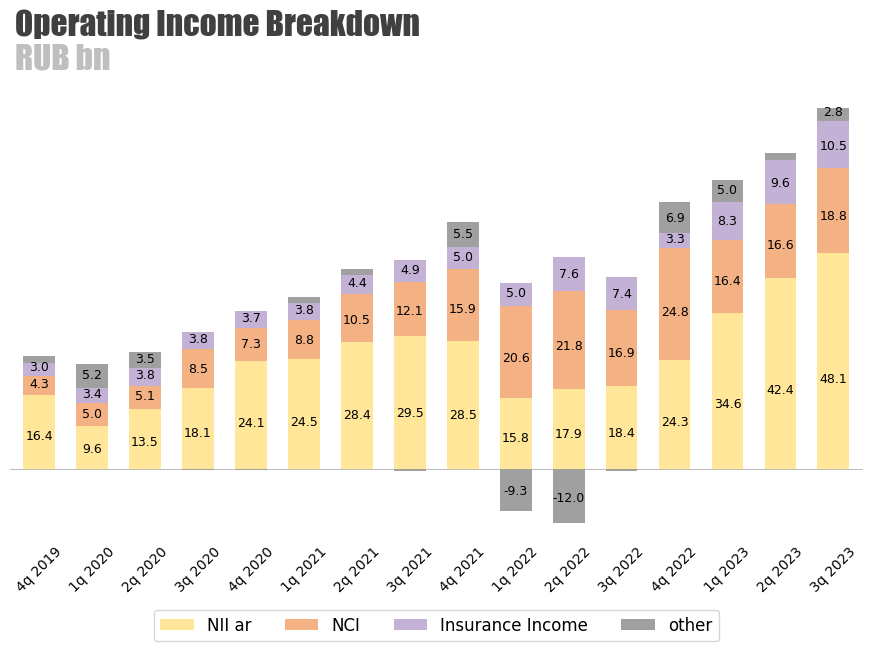

In [15]:
op_colors = np.append(np.array(tcsg_colors)[[0,2,5]],colors[-1])
other_oper_inc = np.sum(val_plq.iloc[[10,11,12,13,17], -quarters_analysed:], axis=0)
oper_inc = pd.DataFrame(np.array([val_plq.iloc[6, -quarters_analysed:], net_commission, insurance_net, other_oper_inc]),
                        index=['NII ar', 'NCI', 'Insurance Income', 'other'],
                        columns = dates_q).T
oper_inc.index.name = None                      


op_graph = oper_inc.plot(kind='bar', figsize=(11,6), stacked=True, color=op_colors, 
                xlabel='', rot=45, width=0.6)
op_graph.yaxis.set_visible(False)
op_graph.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=4, fontsize=12)
op_graph.set_ylim(min(oper_inc.min())*1.2, np.sum(oper_inc, axis=1).max()*1.2)
op_graph.text(-0.45, np.sum(oper_inc, axis=1).max()*1.2, 'Operating Income Breakdown', fontsize=24, **font, color=f_colors[0])    
op_graph.text(-0.45, np.sum(oper_inc, axis=1).max()*1.11, 'RUB bn', fontsize=24, **font, color=f_colors[1])    
op_graph.xaxis.set_ticks_position('none')
op_graph.margins(x=0.01)
op_graph.set_ylim(min(oper_inc.min())*1.2, np.sum(oper_inc, axis=1).max()*1.1)
for key, spine in op_graph.spines.items():
    spine.set_visible(False)
for i in range(oper_inc.shape[0]):
    for j in range(oper_inc.shape[1]):
        if oper_inc.iloc[i,j] > 2:
            op_graph.text(i, np.sum(oper_inc.iloc[i,:j+1], axis=0) - oper_inc.iloc[i,j]*0.6, str(round(oper_inc.iloc[i,j],1)), 
                      ha='center', fontsize=9)
        elif (oper_inc.iloc[i,j] > -1) and (oper_inc.iloc[i,j] < 2):
            pass
        else:
            op_graph.text(i, oper_inc.iloc[i,j]*0.6, str(round(oper_inc.iloc[i,j],1)), 
                      ha='center', fontsize=9)
op_graph.axhline(y=0, color=colors[-1], linewidth=0.5)


Operating expenses

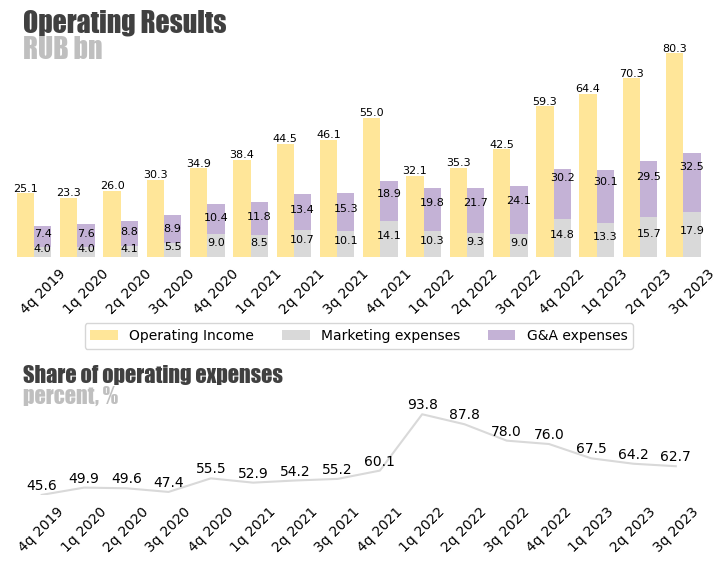

In [16]:
oper_exp = -val_plq.iloc[[9,16], -quarters_analysed:]
exp_labels = ['Marketing expenses', 'G&A expenses']
oper_inc_sum = np.sum(oper_inc, axis=1)
oper_exp_perc = np.sum(oper_exp, axis=0) / np.array(oper_inc_sum) * 100
width_exp = 0.4


oper_epx_graph, (opx,opxp) = plt.subplots(2,1, figsize=(9,6), height_ratios=(2,1))
opx.bar(dates_line - width_exp, oper_inc_sum, color=tcsg_colors[0], width=width_exp, label='Operating Income')
for i in range(oper_exp.shape[0]):
    opx.bar(dates_line, oper_exp, bottom = np.sum(oper_exp.iloc[:i], axis=0),color=tcsg_colors[4+i], width=width_exp, label=exp_labels[i])
for i in range(oper_inc_sum.shape[0]):
    opx.text(dates_line[i] - width_exp, oper_inc_sum.iloc[i]+0.7, str(round(oper_inc_sum.iloc[i],1)),
            ha='center', fontsize=8)
for i in range(oper_exp.shape[0]):
    for j in range(oper_exp.shape[1]):
        opx.text(dates_line[j], np.sum(oper_exp.iloc[:1+i,j], axis=0) - oper_exp.iloc[i,j]*0.5, str(round(oper_exp.iloc[i,j], 1)),
                 ha = 'center', fontsize=8)
opx.xaxis.set_tick_params(rotation=45, labelsize=10)
opx.yaxis.set_visible(False)
opx.set_xticks(dates_line, dates_q)
opx.set_ylim(0, oper_inc_sum.max()*1.1)
opx.text(-0.45, oper_inc_sum.max()*1.1, 'Operating Results', fontsize=20, **font, color=f_colors[0])    
opx.text(-0.45, oper_inc_sum.max()*0.97, 'RUB bn', fontsize=20, **font, color=f_colors[1])    
opx.xaxis.set_ticks_position('none')
opx.margins(x=0.01)
opx.legend(loc='lower center', bbox_to_anchor=(0.5,-0.44), ncol=3)
for key, spine in opx.spines.items():
    spine.set_visible(False)
plt.subplots_adjust(hspace=0.75)
opxp.plot(dates_q, oper_exp_perc, color=tcsg_colors[4])
opxp.xaxis.set_tick_params(rotation=45, labelsize=10)
opxp.yaxis.set_visible(False)
opxp.set_ylim(oper_exp_perc.min(), oper_exp_perc.max()*1.2)
opxp.text(-0.45, oper_exp_perc.max()*1.2, 'Share of operating expenses', fontsize=16, **font, color=f_colors[0])    
opxp.text(-0.45, oper_exp_perc.max()*1.07, 'percent, %', fontsize=16, **font, color=f_colors[1])    
opxp.xaxis.set_ticks_position('none')
opxp.margins(x=0.05)
for key, spine in opxp.spines.items():
    spine.set_visible(False)
for i in range(oper_exp_perc.shape[0]):
    opxp.text(dates_q.iloc[i], oper_exp_perc.iloc[i]+3, str(round(oper_exp_perc.iloc[i],1)),
                 ha='center', fontsize=10)

Profits

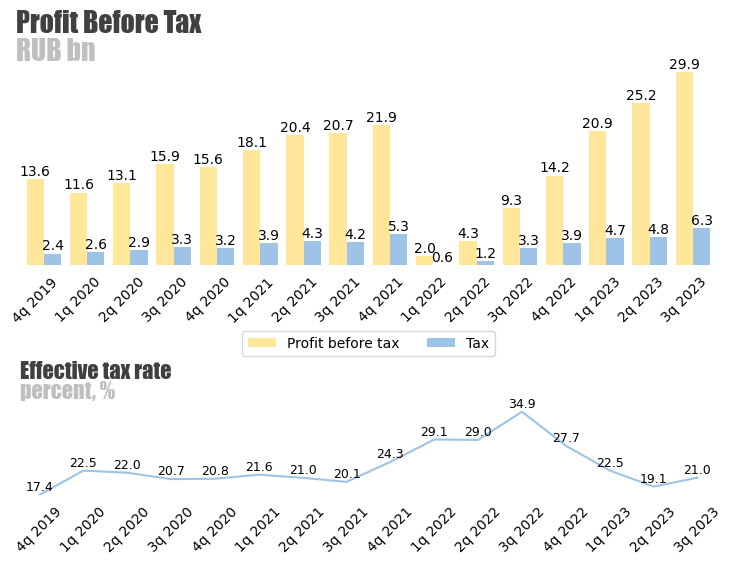

In [17]:

profits = pd.DataFrame([val_plq.iloc[18,-quarters_analysed:], -val_plq.iloc[19,-quarters_analysed:]])
tax_rate = profits.iloc[1] / profits.iloc[0] *100
labels_prof = ['Profit before tax', 'Tax', 'Net profit']
prof_width = 0.4


profits_graph, (pbt, taxr) = plt.subplots(2,1 , figsize=(9,6), height_ratios=(2,1))
for i in range(profits.shape[0]):
    pbt.bar(dates_line + prof_width * i, profits.iloc[i], color=tcsg_colors[i], label=labels_prof[i], width=prof_width)
for i in range(profits.shape[0]):
    for j in range(profits.shape[1]):
        pbt.text(dates_line[j] + prof_width * i, profits.iloc[i, j]+0.5, str(round(profits.iloc[i, j],1)),
                 ha = 'center', fontsize=10)
pbt.set_xticks(dates_line, dates_q)
pbt.xaxis.set_tick_params(rotation=45, labelsize=10)
pbt.xaxis.set_ticks_position('none')
pbt.yaxis.set_visible(False)
for key, spines in pbt.spines.items():
    spines.set_visible(False)
pbt.set_ylim(min(profits.iloc[:2].min()), max(profits.iloc[:2].max())*1.2)
pbt.text(-0.45, max(profits.iloc[:2].max())*1.2, 'Profit Before Tax', fontsize= 20, **font, color=f_colors[0])
pbt.text(-0.45, max(profits.iloc[:2].max())*1.06, 'RUB bn', fontsize= 20, **font, color=f_colors[1])
pbt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.42), ncol=2)
pbt.margins(x=0.01)
plt.subplots_adjust(hspace=0.65)
taxr.plot(dates_q, tax_rate, color=tcsg_colors[1])
taxr.xaxis.set_tick_params(rotation=45, labelsize=10)
taxr.xaxis.set_ticks_position('none')
taxr.yaxis.set_visible(False)
taxr.margins(x=0.03)
for key, spines in taxr.spines.items():
    spines.set_visible(False)
taxr.set_ylim(tax_rate.min(), tax_rate.max()*1.2)
taxr.text(-0.45, tax_rate.max()*1.2, 'Effective tax rate', fontsize= 16, **font, color=f_colors[0])
taxr.text(-0.45, tax_rate.max()*1.08, 'percent, %', fontsize= 16, **font, color=f_colors[1])
for i in range(tax_rate.shape[0]):
    taxr.text(dates_q.iloc[i], tax_rate.iloc[i]+0.8, str(round(tax_rate.iloc[i],1)),
              ha='center', fontsize=9)
    

Net Profit

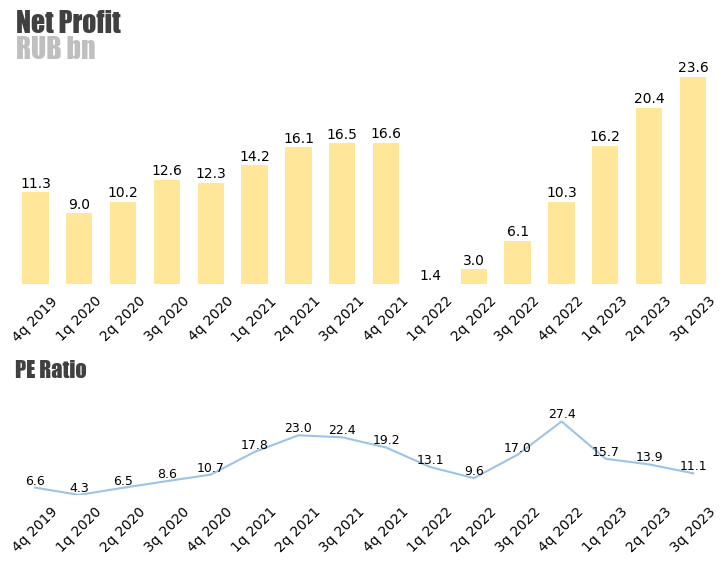

In [18]:
net_prof_growth = val_plq.iloc[-1, -quarters_analysed-4:].pct_change(periods=4).drop(index=val_plq.iloc[-1, -quarters_analysed-4:].index[0:4]) * 100
net_profit = val_plq.iloc[-1, -quarters_analysed:] 
pe_ratio = val_fr.iloc[30, -quarters_analysed:]


net_profits_graph, (nprf, nprg) = plt.subplots(2,1 , figsize=(9,6), height_ratios=(2,1))
nprf.bar(dates_q, net_profit, color=tcsg_colors[0], width=0.6)
for i in range(net_profit.shape[0]):
    nprf.text(dates_q.iloc[i], net_profit.iloc[i]+0.5, str(round(net_profit.iloc[i],1)),
              ha = 'center', fontsize=10)
nprf.xaxis.set_tick_params(rotation=45, labelsize=10)
nprf.xaxis.set_ticks_position('none')
nprf.yaxis.set_visible(False)
for key, spines in nprf.spines.items():
    spines.set_visible(False)
nprf.set_ylim(net_profit.min(), net_profit.max()*1.2)
nprf.text(-0.45, net_profit.max()*1.2, 'Net Profit', fontsize= 20, **font, color=f_colors[0])
nprf.text(-0.45, net_profit.max()*1.08, 'RUB bn', fontsize= 20, **font, color=f_colors[1])
nprf.margins(x=0.01)
plt.subplots_adjust(hspace=0.45)
nprg.plot(dates_q, pe_ratio, color=tcsg_colors[1])
nprg.xaxis.set_tick_params(rotation=45, labelsize=10)
nprg.xaxis.set_ticks_position('none')
nprg.yaxis.set_visible(False)
nprg.margins(x=0.03)
for key, spines in nprg.spines.items():
    spines.set_visible(False)
nprg.set_ylim(pe_ratio.min(), pe_ratio.max()*1.6)
nprg.text(-0.45, pe_ratio.max()*1.5, 'PE Ratio', fontsize= 16, **font, color=f_colors[0])
for i in range(pe_ratio.shape[0]):
    nprg.text(dates_q.iloc[i], pe_ratio.iloc[i]+1, str(round(pe_ratio.iloc[i],1)),
              ha='center', fontsize=9)
    

Capital Ratios

(9.2, 24.860000000000003)

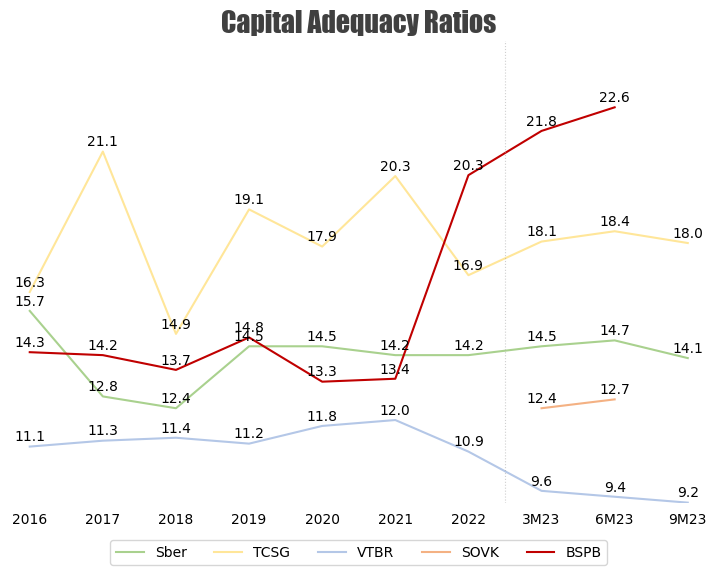

In [19]:
labels_capr = ['Sber', 'TCSG', "VTBR", 'SOVK', 'BSPB']


cap_ratios_graph, cap = plt.subplots(figsize=(9,6))
for i in range(capital_ratios.iloc[1:,1:].shape[0]):
    cap.plot(capital_ratios.iloc[0,1:], capital_ratios.iloc[1+i,1:], color=capr_colors[i], label = labels_capr[i])
for i in range(capital_ratios.iloc[1:,1:].shape[0]):
    for j in range(capital_ratios.iloc[1:,1:].shape[1]):
        if np.isnan(capital_ratios.iloc[1+i,1+j]) == False:
            cap.text(capital_ratios.iloc[0,1+j], capital_ratios.iloc[1+i,1+j]+0.2, str(round(capital_ratios.iloc[1+i,1+j],1)),
             ha = 'center', fontsize = 10)
cap.legend(loc='lower center', bbox_to_anchor=(0.5,-0.15), ncol = capital_ratios.iloc[1:,1:].shape[0])
cap.axvline(x=6.5, ymax = 22, linewidth=0.8, color=colors[-1], alpha=0.5, linestyle='dotted')
cap.xaxis.set_ticks_position('none')
cap.yaxis.set_visible(False)
cap.margins(x=0.03)
cap.set_title('Capital Adequacy Ratios', fontsize= 20, **font, color=f_colors[0])
for key, spines in cap.spines.items():
    spines.set_visible(False)
cap.set_ylim(min(capital_ratios.iloc[1:,1:].min()), max(capital_ratios.iloc[1:,1:].max())*1.1)